# Spatial statistics

In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
# ]
# ///

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">Overview</mark>

In this notebook, we will learn how to assess spatial relationships between objects. Our focus will be on **clustering** and **co-localisation**.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Dataset</mark>
Our data consists of fluorescence images with five channels:
| Channel | Staining | Staining Description |
|---------|---------|----------------|
| 0 | Hoechst | Nuclear stain |
| 1 | Phalloidin | F-actin stain; whole cell marker |
| 2 | Protein A | Spot pattern |
| 3 | Protein B | Spot pattern |
| 4 | Protein C | Spot pattern |

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Analysis Questions</mark>
Our questions are:
* **Are any of proteins A-C clustering?**
* **Are they co-localizing?**
* **Do they localise to the cell membrane?**

To answer these questions, we will introduce the following concepts:
| Concept | Purpose |
|---------|---------|
| `complete spatial randomness Monte Carlo` method | Used to generate random controls |
| `KD-tree` | Used for efficient neighbor search |
| `nearest neighbor` metric | A metric to quantify spatial proximity |
| `Clark-Evans index` | A metric to quantify spatial proximity |
| `Ripleys L` | A metric to quantify spatial proximity |

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">0. Importing libraries</mark>

In [3]:
def overlay(image=None, label_mask=None, df=None, id_col=None, measurement_col=None,
            alpha=0.3, cmap=None, figsize=(8, 8), vmin=None, vmax=None,
            coordinates=None, focus_object=None):
    """
    Overlay a segmentation mask on an image, color-coded by a measurement.

    Parameters
    ----------
    image : 2D array, list of 2D arrays, or (c, y, x) array, or None
        Single image, list of images, or 3D array composited as colored channels:
        1 image: grey | 2: red + cyan | 3: magenta + cyan + yellow.
    label_mask : 2D array, list of 2D arrays, or (c, y, x) array, or None
        Single mask (integer IDs, background=0), list of masks, or 3D array —
        each mask shown in a distinct color. If None, only the image is shown.
    df : pd.DataFrame, optional
        Table with cell IDs and measurements. If None and label_mask is a single
        array, cells are shown with random colors and labeled by ID.
    id_col : str, optional
        Column in df with cell IDs matching label_mask values.
    measurement_col : str or None
        Column to color cells by (categorical or continuous).
    alpha : float
        Overlay opacity (0 = transparent, 1 = opaque).
    cmap : str or None
        Colormap. Defaults: categorical='tab10', continuous='viridis'.
    figsize : tuple
        Figure size in inches. Adjusted automatically when focus_object is set.
    vmin, vmax : float or None
        Continuous colormap range. Defaults to data min/max.
    coordinates : (N, 2) array, or pd.DataFrame with columns 'x', 'y' [, 'channel']
        Points to scatter on top of the image. Array: (row, col) order.
        DataFrame: 'x'/'y' columns; if 'channel' column present, one color per channel.
    focus_object : int or None
        Object ID to zoom into. Crops all data to the object's bounding box
        (with 15% padding) and resizes the figure to match.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    # normalize 3D (c, y, x) arrays to list of 2D arrays
    if isinstance(image, np.ndarray) and image.ndim == 3:
        image = [image[i] for i in range(image.shape[0])]
    if isinstance(label_mask, np.ndarray) and label_mask.ndim == 3:
        label_mask = [label_mask[i] for i in range(label_mask.shape[0])]

    def _normalize(img):
        img = img.astype(float)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        return img

    def _plot_coordinates(ax, coords):
        if coords is None:
            return
        if isinstance(coords, list):
            colors = plt.get_cmap('tab10').colors
            for i, arr in enumerate(coords):
                arr = np.asarray(arr)
                ax.scatter(arr[:, 1], arr[:, 0], s=10,
                        c=[colors[i % len(colors)]],
                        linewidths=0.5, edgecolors='black', label=str(i))
            ax.legend(bbox_to_anchor=(1.01, 0), loc='lower left', title='channel')
        elif isinstance(coords, pd.DataFrame):
            if 'channel' in coords.columns:
                channels = coords['channel'].unique()
                colors = plt.get_cmap('tab10').colors
                for i, ch in enumerate(channels):
                    subset = coords[coords['channel'] == ch]
                    ax.scatter(subset['x'], subset['y'], s=10,
                            c=[colors[i % len(colors)]],
                            linewidths=0.5, edgecolors='black', label=str(ch))
                ax.legend(bbox_to_anchor=(1.01, 0), loc='lower left', title='channel')
            else:
                ax.scatter(coords['x'], coords['y'], s=10,
                        c='yellow', linewidths=0.5, edgecolors='black')
        else:
            coords = np.asarray(coords)
            ax.scatter(coords[:, 1], coords[:, 0], s=10,
                    c='yellow', linewidths=0.5, edgecolors='black')

    # compute crop region from focus_object
    crop = None
    if focus_object is not None:
        masks_for_crop = label_mask if isinstance(label_mask, list) else ([label_mask] if label_mask is not None else [])
        for m in masks_for_crop:
            region = np.argwhere(m == focus_object)
            if len(region) > 0:
                y_min, x_min = region.min(axis=0)
                y_max, x_max = region.max(axis=0)
                pad = int(max(y_max - y_min, x_max - x_min) * 0.15)
                mask_h, mask_w = m.shape
                crop = (max(0, y_min - pad), min(mask_h, y_max + pad),
                        max(0, x_min - pad), min(mask_w, x_max + pad))
                break

    def _apply_crop(arr):
        if arr is None or crop is None:
            return arr
        y0, y1, x0, x1 = crop
        return arr[y0:y1, x0:x1]

    def _offset_coordinates(coords):
        if coords is None or crop is None:
            return coords
        y0, y1, x0, x1 = crop
        if isinstance(coords, list):
            result = []
            for arr in coords:
                arr = np.asarray(arr, dtype=float).copy()
                in_crop = (arr[:, 0] >= y0) & (arr[:, 0] < y1) & \
                        (arr[:, 1] >= x0) & (arr[:, 1] < x1)
                arr = arr[in_crop]
                arr[:, 0] -= y0
                arr[:, 1] -= x0
                result.append(arr)
            return result
        elif isinstance(coords, pd.DataFrame):
            coords = coords.copy()
            in_crop = (coords['x'] >= x0) & (coords['x'] < x1) & \
                    (coords['y'] >= y0) & (coords['y'] < y1)
            coords = coords[in_crop]
            coords['x'] = coords['x'] - x0
            coords['y'] = coords['y'] - y0
        else:
            coords = np.asarray(coords, dtype=float).copy()
            in_crop = (coords[:, 0] >= y0) & (coords[:, 0] < y1) & \
                    (coords[:, 1] >= x0) & (coords[:, 1] < x1)
            coords = coords[in_crop]
            coords[:, 0] -= y0
            coords[:, 1] -= x0
        return coords


    # adjust figsize to match crop aspect ratio
    _figsize = figsize
    if crop is not None:
        y0, y1, x0, x1 = crop
        w_px, h_px = x1 - x0, y1 - y0
        scale = max(figsize)
        _figsize = (scale * w_px / max(w_px, h_px), scale * h_px / max(w_px, h_px))

    # --- multiple images: composite colored channels ---
    if isinstance(image, list):
        n = len(image)
        if n > 3:
            raise ValueError(f"At most 3 images can be composited. Got {n}.")
        channel_colors = {
            1: [(1, 1, 1)],
            2: [(1, 0, 0), (0, 1, 1)],
            3: [(1, 0, 1), (0, 1, 1), (1, 1, 0)],
        }[n]
        imgs = [_normalize(img)[:, :, 0] for img in image]
        h, w = imgs[0].shape
        composite = np.zeros((h, w, 3))
        for img, color in zip(imgs, channel_colors):
            for c in range(3):
                composite[:, :, c] += img * color[c]
        img_display = np.clip(composite, 0, 1)
    elif image is not None:
        img_display = _normalize(image)
    else:
        img_display = None

    img_display = _apply_crop(img_display)
    coordinates = _offset_coordinates(coordinates)

    # --- multiple masks: one color per mask ---
    if isinstance(label_mask, list):
        mask_colors = [
            (1, 0.10, 0.11),
            (0.42, 0.67, 1),
            (0.20, 1, 0.17),
            (0.60, 0.31, 0.64),
            (1.00, 0.50, 0.00),
        ]
        cropped_masks = [_apply_crop(m) for m in label_mask]
        h, w = cropped_masks[0].shape
        multi_overlay = np.zeros((h, w, 4))
        for mask, color in zip(cropped_masks, mask_colors):
            region = mask > 0
            multi_overlay[region, :3] = color
            multi_overlay[region, 3] = alpha

        fig, ax = plt.subplots(figsize=_figsize)
        ax.imshow(img_display if img_display is not None else np.zeros((h, w, 3)))
        ax.imshow(multi_overlay)
        ax.axis('off')
        _plot_coordinates(ax, coordinates)
        return fig, ax

    # --- no mask: show image only ---
    if label_mask is None:
        fig, ax = plt.subplots(figsize=_figsize)
        ax.imshow(img_display)
        ax.axis('off')
        _plot_coordinates(ax, coordinates)
        return fig, ax

    # --- single mask + measurement overlay ---
    label_mask = _apply_crop(label_mask)
    h, w = label_mask.shape
    overlay_rgba = np.zeros((h, w, 4), dtype=float)

    if df is None:
        rng = np.random.default_rng(42)
        cell_ids = np.unique(label_mask[label_mask > 0])
        colors = rng.random((len(cell_ids), 3))
        centroids = {}
        for cell_id, color in zip(cell_ids, colors):
            overlay_rgba[label_mask == cell_id] = [*color, alpha]
            centroids[cell_id] = np.argwhere(label_mask == cell_id).mean(axis=0)

    elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
        if cmap is None:
            cmap = 'tab10'
        categories = df[measurement_col].unique()
        color_map = dict(zip(categories, plt.get_cmap(cmap).colors[:len(categories)]))
        id_to_color = {cell_id: color_map[val] for cell_id, val in zip(df[id_col], df[measurement_col])}
        for cell_id, color in id_to_color.items():
            overlay_rgba[label_mask == cell_id] = [*mcolors.to_rgb(color), alpha]

    else:
        if cmap is None:
            cmap = 'viridis'
        values = df[measurement_col]
        norm = mcolors.Normalize(
            vmin=vmin if vmin is not None else values.min(),
            vmax=vmax if vmax is not None else values.max()
        )
        colormap = plt.get_cmap(cmap)
        id_to_value = dict(zip(df[id_col], values))
        for cell_id, value in id_to_value.items():
            overlay_rgba[label_mask == cell_id] = [*colormap(norm(value))[:3], alpha]

    fig, ax = plt.subplots(figsize=_figsize)
    ax.imshow(img_display if img_display is not None else np.zeros((h, w, 3)))
    ax.imshow(overlay_rgba)
    ax.axis('off')

    if df is None:
        for cell_id, yx in centroids.items():
            ax.text(yx[1], yx[0], str(cell_id), ha='center', va='center', fontsize=6, color='white')
        ax.set_title('Segmentation overlay')
    elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
        legend_handles = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[cat], label=cat, markersize=10)
            for cat in categories
        ]
        ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc='upper left')
        ax.set_title(measurement_col)
    else:
        fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=measurement_col, shrink=0.7)
        ax.set_title(measurement_col)

    _plot_coordinates(ax, coordinates)
    return fig, ax


***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">2. Load image, mask and spot table</mark>
First, we load all the data that we will need for this notebook.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Visualy inspect the images, masks and spots</mark>
To be sure that the data we are workin with is corrects, we visualise it here.

Using the `focus` attribute in `overlay` we can zoom in to view single objects.

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">3. Make An Analysis Plan</mark>

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Question</mark>
Are the spots clustered?

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Approach </mark>
To answer this question, we need to first define a reference for comparison. A common comparison is **complete spatial randomness (CSR)** (i.e., a fully random distribution of points). We can then define a metric that measures if a collection of points are clustered, and then use this metric to compare our dataset collection of points to a collection of random points. 

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Metric for Clustering</mark>
Here, we use the **average distance of each point to its nearest neighbour** as the metric for clustering.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Workflow</mark>

#### 1. Generate a reference for comparison
Randomly distributed set of points inside each cell's cytoplasm. We will call this the **random dataset**, which we will compare to our **protein dataset**.

#### 2. Measure the nearest neighbor distance
For each spot, identify the closest spot within a cell and measure the distance. 

#### 3. Calculate the average nearest neighbour distance
For each dataset, calculate the average nearest neighbor distance for a spot.  

#### 4. Calculate the Clark-Evans Index
The Clark-Evans Index is a ratio between the average nearest neighbour distances for the **protein dataset** and the **random dataset**. This index represents how random or clustered the dot protein distribution is.
    - **Ratio = 1:** The distribution is random 
    - **Ratio > 1:** The distribution is clusered

#### 5. Calculate the p-value of the Clark-Evans Index
Calculate the p-value using a comparison of multiple random patterns.


To start, we focus on **Protein A (Channel 2).**

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">4. Assemble the Protein Dataset and the Random Dataset</mark>

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Protein Dataset: Map spots to cells and count spots per cell</mark>
We need to know how many points are within each cell to place the same number of random points in the next step. If we would generate more or less random points, we would artificially measure clustering or dispersion.

First we generate a dataframe for the cells by using `regionprops_table`.

Then we count the spots per cell (like in Exercise B: Nested Objects).

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Random Dataset: Generate random points</mark>
Let's generate our first set of random points. To make it more transparent, let's focus on a single cell first.

We can use a pre-written function to generate the random points. In short, what it does is:
* It calculates the bounding box of the cell (the box that touches the edge of the cell at every side).
* It draws random points inside that box and tests if they fall within the cell.
    * If not, the point is discarded.
    * If it is within the cell it is kept.
This sequence is repeated until the cell contains the specified number of points.

This procedure is necessary since cells have irregular shapes.

In [12]:
def random_points_in_mask(mask, cell_label, n):
    """
    Generate n random points uniformly distributed within a labeled cell region.

    Points are placed continuously using rejection sampling:
    candidate points are drawn uniformly from the bounding box of the cell and
    accepted only if they fall within the cell mask. This correctly handles
    irregular cell shapes and serves as a null model for Complete Spatial
    Randomness (CSR).

    Parameters
    ----------
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID
        and background is 0.
    cell_label : int
        ID of the cell to sample within.
    n : int
        Number of random points to generate.

    Returns
    -------
    points : (n, 2) numpy array
        Random point coordinates in (row, col) / (y, x) order.
    """
    ys, xs = np.where(mask == cell_label)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    points = []
    while len(points) < n:
        y = np.random.uniform(y_min, y_max)
        x = np.random.uniform(x_min, x_max)
        if mask[int(round(y)), int(round(x))] == cell_label:
            points.append([y, x])
    return np.array(points)


Look up how many points are in our cell of interest.

Create the same number of random points inside that cell.

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">5. Calculate Nearest Neighbor Distances</mark>

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Identifying Neighbors: KD Trees</mark>
Now that we have two sets of points, our protein dataset and the random dataset as a control, we can find the nearest neighbour of every point and calculate the distance. To find neighbors, we will use a `KD tree`, a spatial partitioning algorithm that identies neighbours very effectively.

The syntax for the KD tree function is a bit strange at first: 
```python
KDtree(points_A).query(points_B, k=k)
```

- `KDTree(points_A)` builds the KD tree data structure. 
- `.query(points_B, k=k)` computes the distance to the nearest neighbors. It measures the distance from every point in `points_B` to the `k` nearest neighbours in `points_A`. If the two point sets are the same (like in our case), the first distance will be 0, since it is the distance from each point to itself.

We do the same for the random spots.

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">6. Calculate the Clark-Evans Index for the protein and random datasets</mark>

Now, let's calculate the mean nearest neighbour distances for both spot patterns and compare them using the Clark-Evans Index.

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">7. Repeat Steps 4-6 with Multiple Random Patterns</mark>

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Concept</mark>
A single random pattern as a control dataset is not a reliable comparison because a random patten could be clustered by chance. To account for this possibility, we repeat this procedure with additional random patterns.

Can we trust this metric now? A little more, but it would be great to have a p-value. We can calculate the p-value by asking 'In what fraction of the runs was the observed NN distance smaller than random?'.

The fraction of `True`s in this list is our p-value. 

* Clustered spots → NND_observed is small → most simulations produce a larger NND → few simulations have NND_sim ≤ NND_obs → p close to 0
* Random spots → NND_observed is typical → roughly half the simulations fall below it → p ≈ 0.5

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">8. Repeat Measurements for All Cells</mark>

So far, we have focussed on one single cell. Of course, we need to analyse all cells. 

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Summarise the per-cell clustering analysis as a function</mark>

To make processing individual cells simpler, we can summarise our above analysis in a function called `NNDist`.
The function should have the following features:

**Parameters:**
* spots : (n, 2) numpy array
    Spot coordinates in (row, col) / (y, x) order.
* mask : 2D numpy array
    Label mask where each cell is identified by a unique integer ID.
* cell_id : int
    ID of the cell in mask that spots belong to.
* n_repeats : int
    Number of CSR simulations to run.

**Returns**
* spot_dist_avg : float
    Mean nearest-neighbor distance of the observed spots.
* rnd_dist_avg : float
    Mean of the per-simulation mean nearest-neighbor distances under CSR.
* clark_evans : float
    Clark-Evans index: spot_dist_avg / rnd_dist_avg.
* p_value : float
    Fraction of CSR simulations with mean NND <= spot_dist_avg.


***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">9. Perform the Same Calculation on the Other Channels</mark>
Let's use the tools we developed above to see if the spots in the other channels.

**Channel 1**

**Channel 2**

It seems like **protein A is not clustered**, **protein B is clustering** and protein C is a little ambigous. 

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">10. Measure the Length Scale of Clustering: Ripleys L Function</mark>
We know that Protein B is clustered compared to random. However, we don't know what scale the clustering is occurring on. 

A common method to investigate the length scales of spatial patterns is **Ripley's L function**. The idea is to calculate the density of spots around each spot for different radii and compare that to a random point pattern. The density of a random pattern is independent of the radius, while clustered points will exhibit higher density at shorter radii than longer ones. This way we can infer the average cluster size and distance between clusters.

Here, we only demonstrate the concept on the spot pattern of protein B in one cell. 

In [33]:
from scipy.ndimage import binary_erosion

def RipleysL(spots, mask, cell_id, n_repeats, r_values=None):
    """
    Compute Ripley's L function for spots in a cell against a CSR null model,
    using a Monte Carlo envelope from simulated random point patterns.

    Returns the centered L function L(r) - r, which is 0 under CSR.
    Positive values indicate clustering at scale r, negative values indicate
    dispersion. Border correction is applied via mask erosion: only points at
    least r pixels from the cell boundary are used as source points.

    Parameters
    ----------
    spots : (n, 2) numpy array
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that spots belong to.
    n_repeats : int
        Number of CSR simulations to run.
    r_values : 1D array or None
        Radii at which to evaluate L(r) - r. Defaults to 30 values from 0
        to half the cell's effective radius.

    Returns
    -------
    r_values : 1D array
        Radii at which L(r) - r was evaluated.
    L_observed : 1D array
        L(r) - r for the observed spots.
    L_sims : (n_repeats, len(r_values)) array
        L(r) - r for each CSR simulation. Use .min(axis=0) / .max(axis=0)
        for the envelope, .mean(axis=0) for the expected value under CSR.
    """
    cell_mask = mask == cell_id
    area = cell_mask.sum()
    n_points = spots.shape[0]

    if r_values is None:
        r_max = np.sqrt(area / np.pi) * 0.5
        r_values = np.linspace(0, r_max, 30)

    # precompute eroded masks for each r — done once, not per simulation
    eroded_masks = []
    for r in r_values:
        r_int = int(np.ceil(r))
        size = 2 * r_int + 1
        cy, cx = np.ogrid[-r_int:size - r_int, -r_int:size - r_int]
        struct = cy**2 + cx**2 <= r**2
        eroded_masks.append(binary_erosion(cell_mask, structure=struct))

    def compute_L(coords):
        tree = KDTree(coords)
        K = []
        for r, eroded in zip(r_values, eroded_masks):
            valid = eroded[coords[:, 0].astype(int), coords[:, 1].astype(int)]
            n_valid = valid.sum()
            if n_valid == 0:
                K.append(np.nan)
                continue
            count = sum(len(tree.query_ball_point(p, r)) - 1 for p in coords[valid])
            K.append((area / (n_valid * n_points)) * count)
        return np.sqrt(np.array(K) / np.pi) - r_values

    L_observed = compute_L(spots)

    L_sims = []
    for _ in range(n_repeats):
        rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
        L_sims.append(compute_L(rnd_points))

    return r_values, L_observed, np.array(L_sims)


(<Figure size 673.684x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

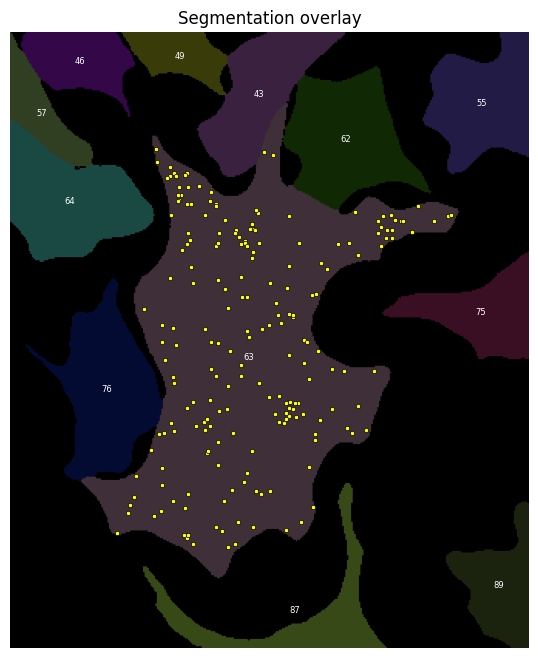

In [34]:
cell_id = 63
spots = df_spots.loc[(df_spots['channel']==1) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()
overlay(label_mask=mask, coordinates=spots, focus_object=cell_id)

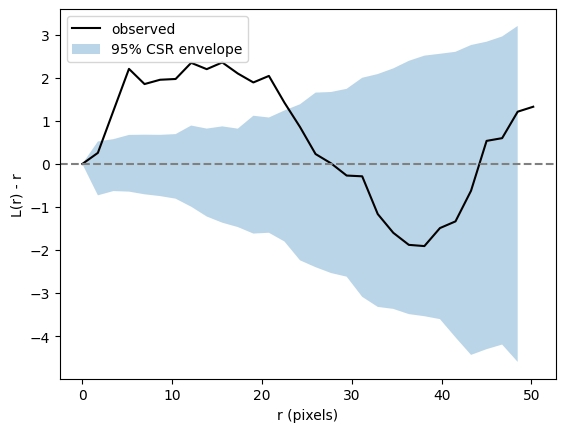

In [35]:
r_values, L_obs, L_sims = RipleysL(spots, mask, cell_id=63, n_repeats=200)

plt.plot(r_values, L_obs, color='black', label='observed')
plt.fill_between(r_values,
                 np.percentile(L_sims, 2.5, axis=0),
                 np.percentile(L_sims, 97.5, axis=0),
                 alpha=0.3, label='95% CSR envelope')

plt.axhline(0, color='grey', linestyle='--')
plt.xlabel('r (pixels)')
plt.ylabel('L(r) - r')
plt.legend()


We observe clustering with scale 2-20 pixels, where the observed curve is above the 95% CSR envelope.

***

<p class="alert alert-info">
    <strong>Eva's Note:</strong> I think we could split the notebook here!
</p>

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">11. Question 2 --> Make An Analysis Plan</mark>

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Question</mark>
Do Protein A spots co-localize with Protein B spots?

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Approach </mark>
Answering this question is very similar to answering the question of if spots are clustered. Instead of finding nearest neighbours for each point within its *own* dataset, we find the nearest neighbours of points in datasset A to points in dataset B.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Workflow</mark>

#### 1. Generate a reference for comparison
Randomly distributed set of points inside each cell's cytoplasm. We will call this the **random dataset**, which we will compare to our **protein datasets**.

#### 2. Measure the nearest neighbor distance
For every spot in dataset A, identify the closest spot in dataset B and measure the distance.

#### 3. Calculate the average nearest neighbour distance
Average the two distances across all spots in the cell.

#### 4. Calculate the Clark-Evans Index
Calculate the ratio of the average A-B distance compared to the A-random distance. 
    - **Ratio = 1:** Spots in dataset B and the spots in the random dataset are both distributed independently of spots in dataset A
    - **Ratio < 1:** Spots in dataset A co-localise with spots in dataset B
    - **Ratio > 1:** Spots in dataset A and B avoid each other  

#### 5. Calculate the p-value of the Clark-Evans Index
Calculate the p-value using a comparison of multiple random patterns.

#### 6. Calculate the reverse direction of comparison
Measure the distance of every spot in dataset B to dataset A, then repeat the analysis. The two directions are not interchangeable. If set B is much denser than A, every A point will happen to be near some B point even at random, making A→B appear co-localized by chance. Measuring B→A guards against this: if B is merely dense everywhere rather than specifically clustering around A, most B points will still be far from A and the ratio will stay near 1. True mutual co-localization produces small ratios in both directions.

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">12. Assemble Datasets</mark>

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Generate random point distribution</mark>
As before, we focus on one cell to illustrate the principles. First, we need to generate two random set of points, one each as a random distribution of the points of protien A and B (same number of points).

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">13. Calculate Nearest Neighbour Distances</mark>
We calculate the nearest neighbour distances from 
* protein A spots to protein B spots
* protein B spots to protein A spots
* protein A spots to randomised B spots
* protien B spots to randomised A spots

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">14. Calculate Clark-Evans Indices</mark>

Now we can calculate our Clark-Evans indices.

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">14. Repeat Steps 12-14 with Multiple Random Patterns</mark>
As before, we need to compare to multiple random patterns.  

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">15. Per-cell Colocalization Measurements</mark>

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Summarise the per-cell co-localisation analysis as a function</mark>

To make processing individual cells simpler, we can summarise our above analysis in a function called `CrossNN`.
The function should have the following features:

**Parameters**
spots_A, spots_B : (n, 2) numpy arrays
    Spot coordinates in (row, col) / (y, x) order.
mask : 2D numpy array
    Label mask where each cell is identified by a unique integer ID.
cell_id : int
    ID of the cell in mask that both spot sets belong to.
n_repeats : int
    Number of CSR simulations to run.

**Returns**
dict with keys:
    nn_AtoB, nn_BtoA : float
        Observed mean cross-NN distance in each direction.
    nn_random_AtoB, nn_random_BtoA : float
        Mean of simulated cross-NN distances under CSR.
    ce_AtoB, ce_BtoA : float
        Cross Clark-Evans index (observed / random). < 1 indicates
        co-localization, > 1 indicates avoidance.
    pval_AtoB, pval_BtoA : float
        Fraction of simulations with cross-NN <= observed.
        Small values indicate significant co-localization.


In [41]:
def CrossNN(spots_A, spots_B, mask, cell_id, n_repeats):
    """
    Test whether two sets of spots are more co-localized than expected under
    CSR using cross nearest-neighbor distances.

    For each point in A, the nearest neighbor in B is found (and vice versa).
    The observed mean cross-NN distances are compared to a null distribution
    where both sets are independently randomized within the cell mask.

    The two directions (A→B and B→A) can differ when the sets have different
    sizes: a small set is always close to a large one even by chance.

    Parameters
    ----------
    spots_A, spots_B : (n, 2) numpy arrays
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that both spot sets belong to.
    n_repeats : int
        Number of CSR simulations to run.

    Returns
    -------
    dict with keys:
        nn_AtoB, nn_BtoA : float
            Observed mean cross-NN distance in each direction.
        nn_random_AtoB, nn_random_BtoA : float
            Mean of simulated cross-NN distances under CSR.
        ce_AtoB, ce_BtoA : float
            Cross Clark-Evans index (observed / random). < 1 indicates
            co-localization, > 1 indicates avoidance.
        pval_AtoB, pval_BtoA : float
            Fraction of simulations with cross-NN <= observed.
            Small values indicate significant co-localization.
    """
    n_A, n_B = spots_A.shape[0], spots_B.shape[0]

    # observed cross-NN distances
    nn_AtoB = KDTree(spots_B).query(spots_A, k=1)[0].mean()
    nn_BtoA = KDTree(spots_A).query(spots_B, k=1)[0].mean()

    sims_AtoB, sims_BtoA = [], []
    for _ in range(n_repeats):
        rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
        rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)
        sims_AtoB.append(KDTree(rnd_B).query(spots_A, k=1)[0].mean())
        sims_BtoA.append(KDTree(rnd_A).query(spots_B, k=1)[0].mean())

    sims_AtoB = np.array(sims_AtoB)
    sims_BtoA = np.array(sims_BtoA)

    return {
        'nn_AtoB':        nn_AtoB,
        'nn_BtoA':        nn_BtoA,
        'nn_random_AtoB': sims_AtoB.mean(),
        'nn_random_BtoA': sims_BtoA.mean(),
        'ce_AtoB':        nn_AtoB / sims_AtoB.mean(),
        'ce_BtoA':        nn_BtoA / sims_BtoA.mean(),
        'pval_AtoB':      (sims_AtoB <= nn_AtoB).mean(),
        'pval_BtoA':      (sims_BtoA <= nn_BtoA).mean(),
    }


In [42]:
spots_A = df_spots.loc[(df_spots['channel']==0) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()
spots_B = df_spots.loc[(df_spots['channel']==1) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()
CrossNN(spots_A=spots_A, spots_B=spots_B, mask=mask, cell_id=cell_id, n_repeats=10)

{'nn_AtoB': np.float64(1.9696171301040926),
 'nn_BtoA': np.float64(3.3610265155268935),
 'nn_random_AtoB': np.float64(6.603303167119867),
 'nn_random_BtoA': np.float64(7.246996725683177),
 'ce_AtoB': np.float64(0.2982775559831174),
 'ce_BtoA': np.float64(0.46378198345467697),
 'pval_AtoB': np.float64(0.0),
 'pval_BtoA': np.float64(0.0)}

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Repeat measurements for all cells</mark>
So far, we have focussed on one single cell. Of course, we need to analyse all cells. 

In [43]:
n_repeats = 10

results = []
for cell_id in df_cell['label'].unique():
    spots_A = df_spots.loc[(df_spots['channel']==0) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()
    spots_B = df_spots.loc[(df_spots['channel']==1) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()
    
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(CrossNN(spots_A=spots_A, spots_B=spots_B, mask=mask, cell_id=cell_id, n_repeats=n_repeats))

df_cell = pd.concat([df_cell, pd.DataFrame(results)], axis=1)
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value,nn_AtoB,nn_BtoA,nn_random_AtoB,nn_random_BtoA,ce_AtoB,ce_BtoA,pval_AtoB,pval_BtoA
0,813.0,6,4,6.386375,5.841208,1.183311,0.5,0.500000,7.040192,2.107554,8.423400,0.237242,0.835790,0.0,0.3
1,12236.0,7,61,6.311969,6.802401,0.931204,0.0,2.043728,5.711784,5.774096,7.714179,0.353948,0.740427,0.0,0.0
2,3897.0,9,19,6.835503,6.882408,1.000944,0.3,1.645157,5.123184,3.874341,7.456071,0.424629,0.687116,0.0,0.1
3,4029.0,10,20,6.454970,6.530639,1.002395,0.4,3.593114,5.122364,4.420370,7.349626,0.812854,0.696956,0.0,0.0
4,2124.0,11,10,6.214888,6.674236,0.941602,0.2,1.700877,8.957093,3.213349,8.099835,0.529316,1.105836,0.0,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,10682.0,104,53,5.318296,7.620668,0.699892,0.0,1.852648,4.067538,5.544458,7.544323,0.334144,0.539152,0.0,0.0
90,6146.0,106,30,5.234533,6.652371,0.792979,0.0,2.548677,5.406141,4.760794,8.318264,0.535347,0.649912,0.0,0.0
91,6745.0,107,33,6.339555,6.902593,0.925239,0.2,1.698497,4.073663,4.703580,7.472306,0.361107,0.545168,0.0,0.0
92,7501.0,108,37,7.490188,7.352563,1.020644,0.7,1.837516,4.194518,4.806957,7.910465,0.382262,0.530249,0.0,0.0


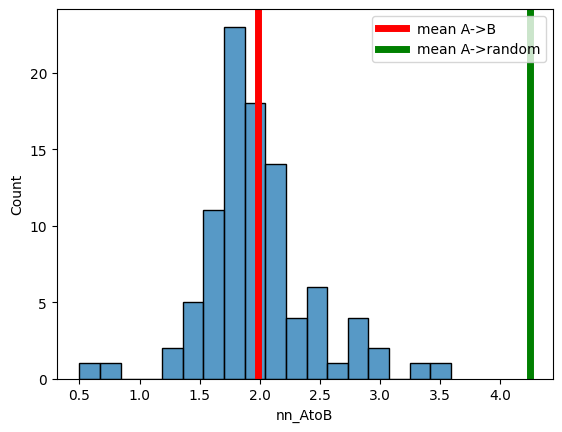

In [56]:
sns.histplot(
    df_cell,
    x='nn_AtoB',
)
plt.axvline(df_cell['nn_AtoB'].mean(), c='red', lw=5, label='mean A->B')
plt.axvline(df_cell['nn_random_AtoB'].mean(), c='green', lw=5, label='mean A->random')
plt.legend()

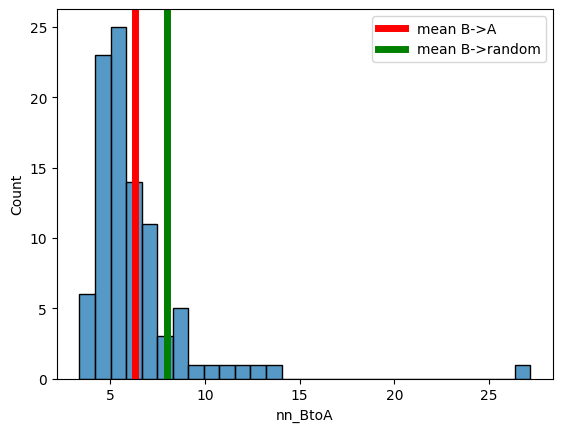

In [57]:
sns.histplot(
    df_cell,
    x='nn_BtoA',
)
plt.axvline(df_cell['nn_BtoA'].mean(), c='red', lw=5, label='mean B->A')
plt.axvline(df_cell['nn_random_BtoA'].mean(), c='green', lw=5, label='mean B->random')
plt.legend()

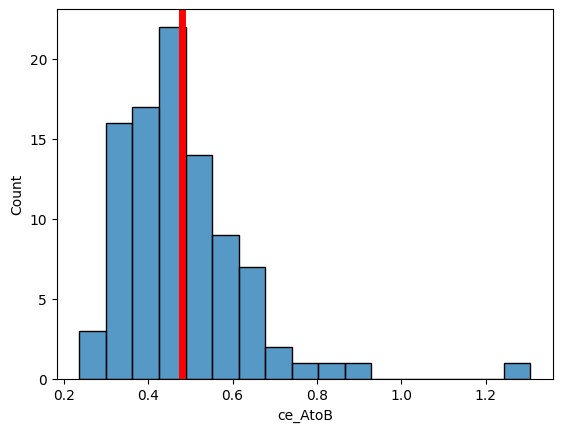

In [51]:
sns.histplot(
    df_cell,
    x='ce_AtoB',
)
plt.axvline(df_cell['ce_AtoB'].mean(), c='red', lw=5)

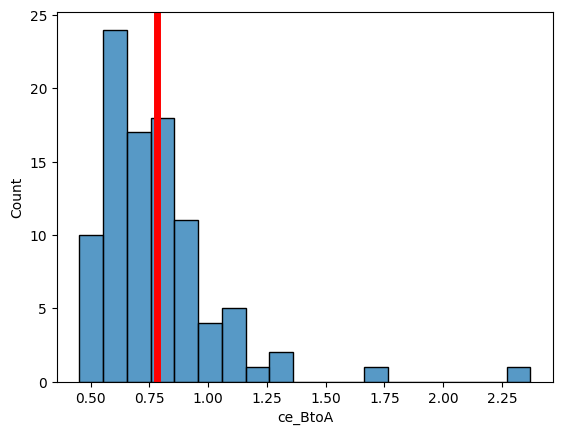

In [52]:
sns.histplot(
    df_cell,
    x='ce_BtoA',
)
plt.axvline(df_cell['ce_BtoA'].mean(), c='red', lw=5)

**Interpretation:** Almost all of protein A associates with protein B but not vice versa. 

***

<p class="alert alert-info">
    <strong>Eva's Note:</strong> I think we could split the notebook here!
</p>

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">16. Question 3 --> Make An Analysis Plan </mark>

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Question</mark>
Does Protein C localize to the cell membrane?

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Approach </mark>
Another common task is to ask whether a distribution of objects is close to a cellular compartment; in this case the cell membrane. At first glance, this question might seem different from what we have done so far, but it is just a variation of the co-localisation analysis we have already done. The key is to transform the cell membrane region into a set of points. This way we can do the exact same analysis as above.

### <mark style="color: black; background-color: rgb(190,223,185); padding: 3px; border-radius: 5px;">Workflow</mark>

#### 1. Generate a reference for comparison
Randomly distributed set of points inside each cell's cytoplasm. We will call this the **random dataset**, which we will compare to our **protein datasets**.

#### 2. Measure the nearest neighbor distance
For every spot in dataset C, identify the closest spot in the cell membrane dataset and measure the distance.

#### 3. Calculate the average nearest neighbour distance
Average the two distances across all spots in the cell.

#### 4. Calculate the Clark-Evans Index
Calculate the ratio of the average C-membrane distance compared to the C-random distance. 
    - **Ratio = 1:** Spots in membrane dataset and the spots in the random dataset are both distributed independently of spots in dataset C
    - **Ratio < 1:** Spots in dataset C co-localise with spots in the membrane dataset
    - **Ratio > 1:** Spots in dataset C and and membrane avoid each other  

#### 5. Calculate the p-value of the Clark-Evans Index
Calculate the p-value using a comparison of multiple random patterns.

#### 6. Calculate the reverse direction of comparison
Measure the distance of every spot in the membrane dataset to dataset C, then repeat the analysis.

***

## <mark style="color: black; background-color: rgb(127,196,125); padding: 3px; border-radius: 5px;">17. Perform the Colocalization Analysis</mark>

### <mark style="color: black; background-color: rgb(252,185,118); padding: 3px; border-radius: 5px;">✍️ Exercise: Perform the analysis</mark>

Use the cross nearest neighbour analysis we developed above to find out if protein C localises preferentially to the cell membrane.

Hints: 
* The code snippet below illustrates how a boolean mask of a whole single cell can be turned into its boundary and subsequently into a list of boundary coordinates (points).
* Think carefully about which populations to randomise and compare.

(<Figure size 674.314x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

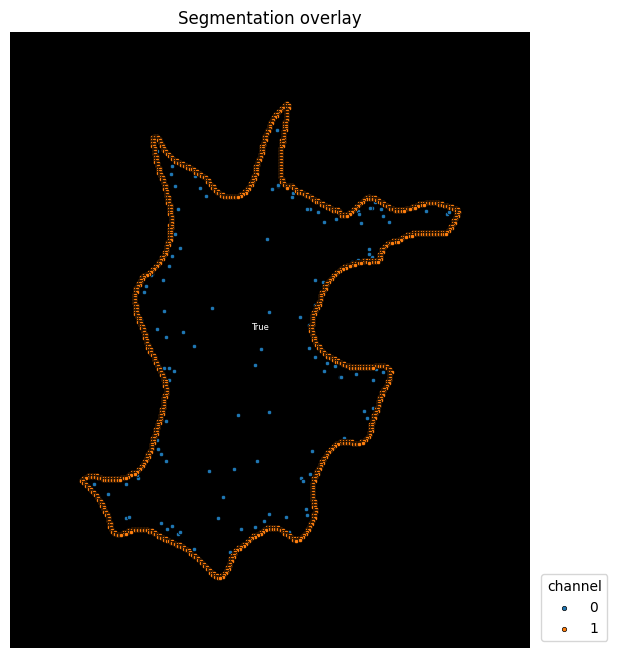

In [74]:
from skimage.segmentation import find_boundaries

cell_id = 63

spots_C = df_spots.loc[(df_spots['channel']==2) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()

boundary = find_boundaries(mask == cell_id)
coords = np.argwhere(boundary)  

overlay(label_mask=boundary, coordinates=[spots_C,  coords],  focus_object=True)

In [75]:
def NNdist_target(spots_from, spots_to, mask, cell_id, n_repeats):
    """
    Calculate the nearest neighbour distance from `spots_from` to `spots_to`.
    """
    
    n_from = spots_from.shape[0]

    # observed NN distances
    nn_obs = KDTree(spots_to).query(spots_from, k=1)[0].mean()

    # randomised NN distances
    sims = []
    for _ in range(n_repeats):
        rnd = random_points_in_mask(mask, cell_label=cell_id, n=n_from)

        sims.append(KDTree(rnd_B).query(rnd, k=1)[0].mean())

    sims = np.array(sims)

    return {
        'nn_observed':    nn_obs,
        'nn_random':      sims.mean(),
        'ce':             nn_obs / sims.mean(),
        'pval':           (sims <= nn_obs).mean(),
    }


In [77]:
n_repeats = 10

results = []
for cell_id in df_cell['label'].unique():
    boundary = find_boundaries(mask == cell_id)
    coords = np.argwhere(boundary)
    spots_C = df_spots.loc[(df_spots['channel']==2) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()
    
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNdist_target(spots_from=spots_C, spots_to=coords, mask=mask, cell_id=cell_id, n_repeats=n_repeats))

df_boundary = pd.DataFrame(results)
df_boundary

,nn_observed,nn_random,ce,pval
0,3.730943,412.027304,0.009055,0.0
1,4.867899,289.938812,0.016789,0.0
2,5.118525,986.041290,0.005191,0.0
3,4.387293,325.795797,0.013466,0.0
4,3.287399,1020.099624,0.003223,0.0
...,...,...,...,...
89,5.160171,222.376031,0.023205,0.0
90,4.033176,830.678799,0.004855,0.0
91,6.320505,653.078410,0.009678,0.0
92,5.492485,731.050070,0.007513,0.0


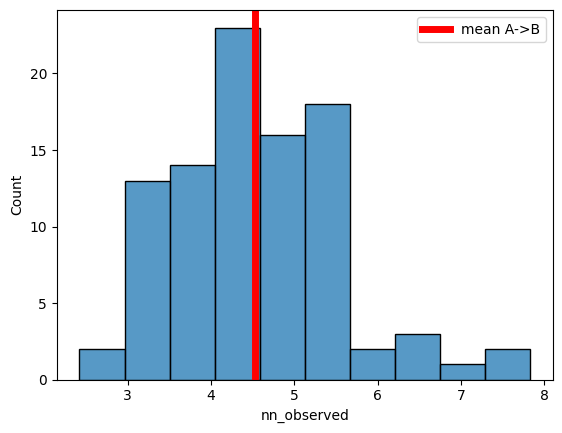

In [84]:
sns.histplot(
    df_boundary,
    x='nn_observed',

)
plt.axvline(df_boundary['nn_observed'].mean(), c='red', lw=5, label='mean A->B')
# plt.axvline(df_boundary['nn_random'].mean(), c='green', lw=5, label='mean A->random')
plt.legend()

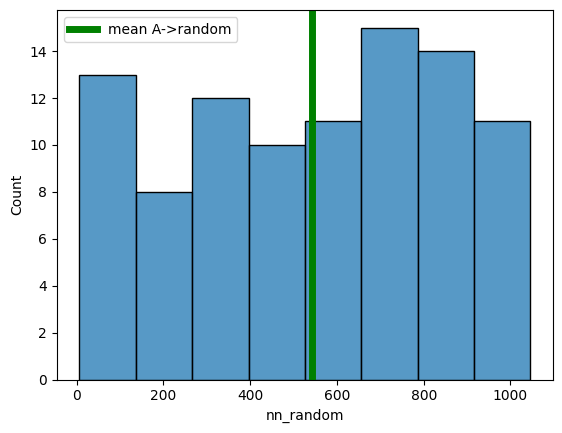

In [83]:
sns.histplot(
    df_boundary,
    x='nn_random',
)
# plt.axvline(df_boundary['nn_observed'].mean(), c='red', lw=5, label='mean A->B')
plt.axvline(df_boundary['nn_random'].mean(), c='green', lw=5, label='mean A->random')
plt.legend()

(0.0, 0.2)

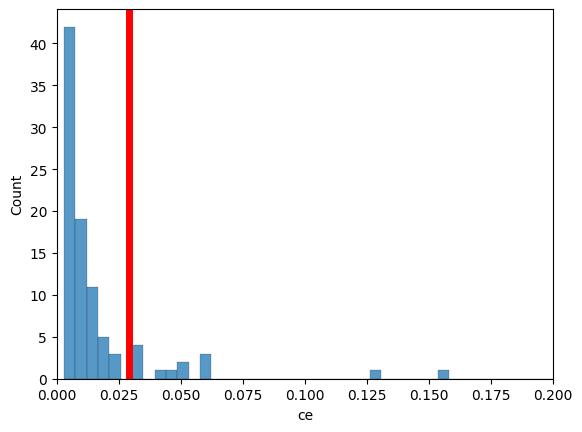

In [85]:
sns.histplot(
    df_boundary,
    x='ce',
)
plt.axvline(df_boundary['ce'].mean(), c='red', lw=5)
plt.xlim(0,0.2)

So, definitely, Protein C localises close to the cell membrane with an average distance of 4.5 pixels.